# 📈 Task 2: Unemployment Analysis in India (Pre & Post COVID-19 Impact)
**Domain**: Data Science & Economic Data Analytics  
**Objective**: Perform Exploratory Data Analysis (EDA) on unemployment data in India to uncover regional and temporal trends, evaluate rural vs. urban dynamics, and measure the economic shock of the COVID-19 pandemic and national lockdown.  
**Author**: Data Science Intern  
**Tech Stack**: Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook  
**Datasets**: `Unemployment in India.csv` & `Unemployment_Rate_upto_11_2020.csv`  


## 1. Environment Setup & Library Imports
We import core scientific and data visualization libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and configure visual aesthetics for clean, publication-ready charts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Visual Aesthetics Setup
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("[OK] Environment setup complete. Libraries imported.")


[OK] Environment setup complete. Libraries imported.


## 2. Dataset Loading & Initial Inspection
We load two complementary datasets:
1. `Unemployment in India.csv`: Monthly unemployment metrics split by **Area (Rural vs. Urban)** from May 2019 to June 2020.
2. `Unemployment_Rate_upto_11_2020.csv`: State-level monthly metrics with **Geographic Coordinates & Macro-Region (Zone)** classifications from January 2020 to October 2020.


In [2]:
# File paths
path_area = r'C:\Users\hp\Desktop\Qiyas\Unemployment in India.csv'
path_rate = r'C:\Users\hp\Desktop\Qiyas\Unemployment_Rate_upto_11_2020.csv'

# Load raw datasets
df_area = pd.read_csv(path_area)
df_rate = pd.read_csv(path_rate)

print("--- Dataset 1: Unemployment in India (Rural/Urban) ---")
print(f"Shape: {df_area.shape[0]} rows x {df_area.shape[1]} columns")
display(df_area.head(3))

print("\n--- Dataset 2: Unemployment Rate Upto 11/2020 (With Zones & Coordinates) ---")
print(f"Shape: {df_rate.shape[0]} rows x {df_rate.shape[1]} columns")
display(df_rate.head(3))


--- Dataset 1: Unemployment in India (Rural/Urban) ---
Shape: 768 rows x 7 columns


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural



--- Dataset 2: Unemployment Rate Upto 11/2020 (With Zones & Coordinates) ---
Shape: 267 rows x 9 columns


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74


## 3. Data Cleaning, Type Conversion & Feature Engineering
Raw datasets often contain trailing spaces in column headers, missing padding rows, and dates stored as text strings.

### Preprocessing Checklist:
1. **Header Normalization**: Strip whitespaces from column names.
2. **Missing Row Audit**: Drop empty rows (`dropna()`).
3. **Date Parsing**: Convert `Date` strings to `datetime64[ns]` using `pd.to_datetime`.
4. **Categorical Sanitization**: Strip leading/trailing whitespaces from string values (`Region`, `Area`, `Frequency`).
5. **Feature Extraction**: Extract `Year`, `Month`, `Month_Name`, `Year_Month`, and classify `COVID_Period` (`Pre-COVID`: <= Feb 2020, `COVID Lockdown`: March 2020 onwards).


In [3]:
# 1. Strip column names
df_area.columns = df_area.columns.str.strip()
df_rate.columns = df_rate.columns.str.strip()

# 2. Drop null padding rows
df_area = df_area.dropna().reset_index(drop=True)
df_rate = df_rate.dropna().reset_index(drop=True)

# 3. Clean string column values
for col in ['Region', 'Area', 'Frequency']:
    if col in df_area.columns:
        df_area[col] = df_area[col].astype(str).str.strip()

for col in ['Region', 'Frequency', 'Region.1']:
    if col in df_rate.columns:
        df_rate[col] = df_rate[col].astype(str).str.strip()

if 'Region.1' in df_rate.columns:
    df_rate.rename(columns={'Region.1': 'Macro_Region'}, inplace=True)

# 4. Convert Date to datetime after stripping leading/trailing whitespace
df_area['Date'] = df_area['Date'].astype(str).str.strip()
df_rate['Date'] = df_rate['Date'].astype(str).str.strip()

df_area['Date'] = pd.to_datetime(df_area['Date'], format='%d-%m-%Y')
df_rate['Date'] = pd.to_datetime(df_rate['Date'], format='%d-%m-%Y')

# 5. Extract temporal features for df_area
df_area['Year'] = df_area['Date'].dt.year
df_area['Month'] = df_area['Date'].dt.month
df_area['Month_Name'] = df_area['Date'].dt.strftime('%b %Y')
df_area['COVID_Period'] = np.where(df_area['Date'] < '2020-03-01', 'Pre-COVID (May 2019 - Feb 2020)', 'COVID Lockdown (Mar 2020 - Jun 2020)')

# Extract temporal features for df_rate
df_rate['Year'] = df_rate['Date'].dt.year
df_rate['Month'] = df_rate['Date'].dt.month
df_rate['Month_Name'] = df_rate['Date'].dt.strftime('%b %Y')
df_rate['COVID_Period'] = np.where(df_rate['Date'] < '2020-03-01', 'Pre-COVID (Jan - Feb 2020)', 'COVID Period (Mar - Oct 2020)')

print("=== Cleaned Data Verification ===")
print("df_area Info:")
df_area.info()
print("\ndf_area Null Count:\n", df_area.isnull().sum())
print("\ndf_area Date Range:", df_area['Date'].min().strftime('%Y-%m-%d'), "to", df_area['Date'].max().strftime('%Y-%m-%d'))


=== Cleaned Data Verification ===
df_area Info:


<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
 7   Year                                     740 non-null    int32         
 8   Month                                    740 non-null    int32         
 9   Month_Name                               740 non-null 

## 4. Exploratory Data Analysis (EDA) & Summary Statistics
We calculate summary statistics for the three core economic indicators:
- **Estimated Unemployment Rate (%)**
- **Estimated Employed** (Count of employed individuals)
- **Estimated Labour Participation Rate (%)**


In [4]:
indicators = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

print("=== Overall Summary Statistics (Unemployment in India Dataset) ===")
display(df_area[indicators].describe().T)

print("\n=== Summary Statistics Grouped by Area (Rural vs Urban) ===")
display(df_area.groupby('Area')[indicators].mean().T)


=== Overall Summary Statistics (Unemployment in India Dataset) ===


,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),740.0,1.178795e+01,1.072130e+01,0.00,4.657500e+00,8.35,1.588750e+01,76.74
Estimated Employed,740.0,7.204460e+06,8.087988e+06,49420.00,1.190404e+06,4744178.50,1.127549e+07,45777509.00
Estimated Labour Participation Rate (%),740.0,4.263012e+01,8.111094e+00,13.33,3.806250e+01,41.16,4.550500e+01,72.57



=== Summary Statistics Grouped by Area (Rural vs Urban) ===


Area,Rural,Urban
Estimated Unemployment Rate (%),1.032479e+01,1.316661e+01
Estimated Employed,1.019285e+07,4.388626e+06
Estimated Labour Participation Rate (%),4.446482e+01,4.090136e+01


## 5. Regional Analysis: Top & Bottom States and Urban vs Rural Comparison
We examine regional variations in unemployment across Indian states to identify geographic hotspots and compare rural versus urban dynamics.


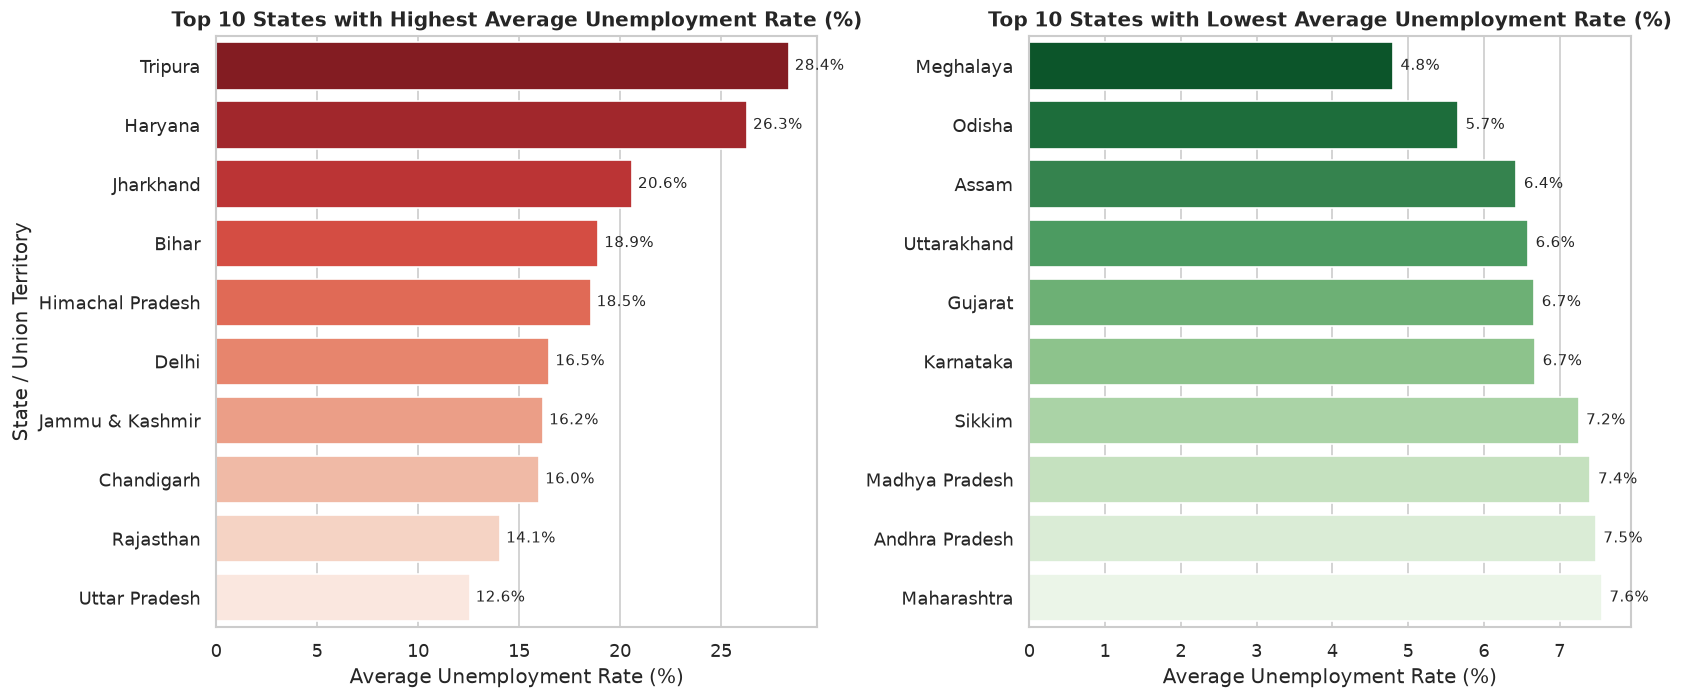

In [5]:
state_avg = df_area.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 Highest Unemployment States
sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=state_avg.head(10), ax=axes[0], palette='Reds_r')
axes[0].set_title("Top 10 States with Highest Average Unemployment Rate (%)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Average Unemployment Rate (%)")
axes[0].set_ylabel("State / Union Territory")

for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'{width:.1f}%', (width + 0.3, p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=9)

# Top 10 Lowest Unemployment States
sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=state_avg.tail(10).iloc[::-1], ax=axes[1], palette='Greens_r')
axes[1].set_title("Top 10 States with Lowest Average Unemployment Rate (%)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Average Unemployment Rate (%)")
axes[1].set_ylabel("")

for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f'{width:.1f}%', (width + 0.1, p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


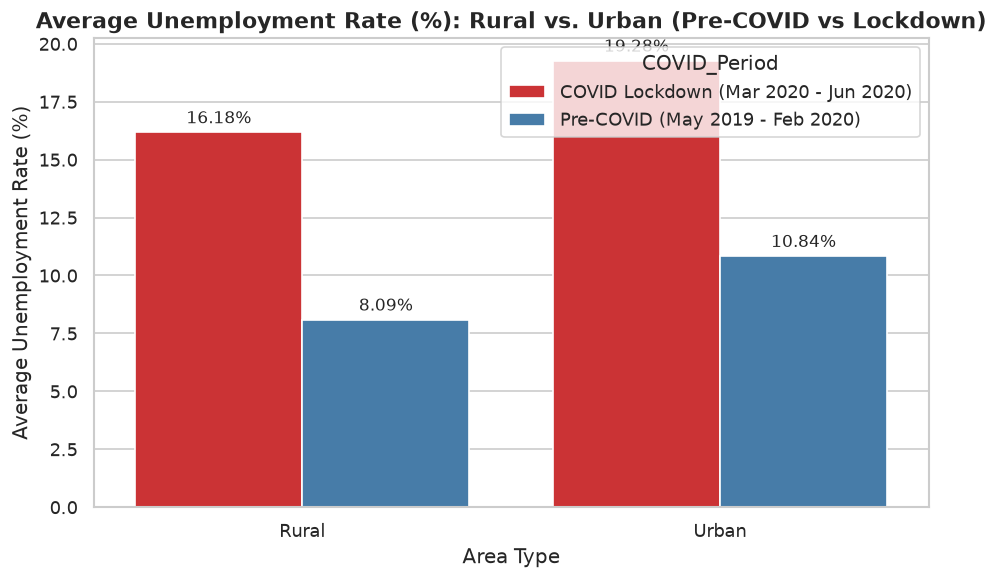

In [6]:
plt.figure(figsize=(8, 5))
area_cmp = df_area.groupby(['Area', 'COVID_Period'])['Estimated Unemployment Rate (%)'].mean().reset_index()

sns.barplot(x='Area', y='Estimated Unemployment Rate (%)', hue='COVID_Period', data=area_cmp, palette='Set1')
plt.title("Average Unemployment Rate (%): Rural vs. Urban (Pre-COVID vs Lockdown)", fontsize=13, fontweight='bold')
plt.ylabel("Average Unemployment Rate (%)")
plt.xlabel("Area Type")

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.2f}%',
                           (p.get_x() + p.get_width() / 2, height),
                           ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


## 6. Temporal & Time-Series Analysis
We analyze how unemployment rates evolved over time across months and track major Indian states through the pre-lockdown baseline and peak COVID lockdown period (April – May 2020).


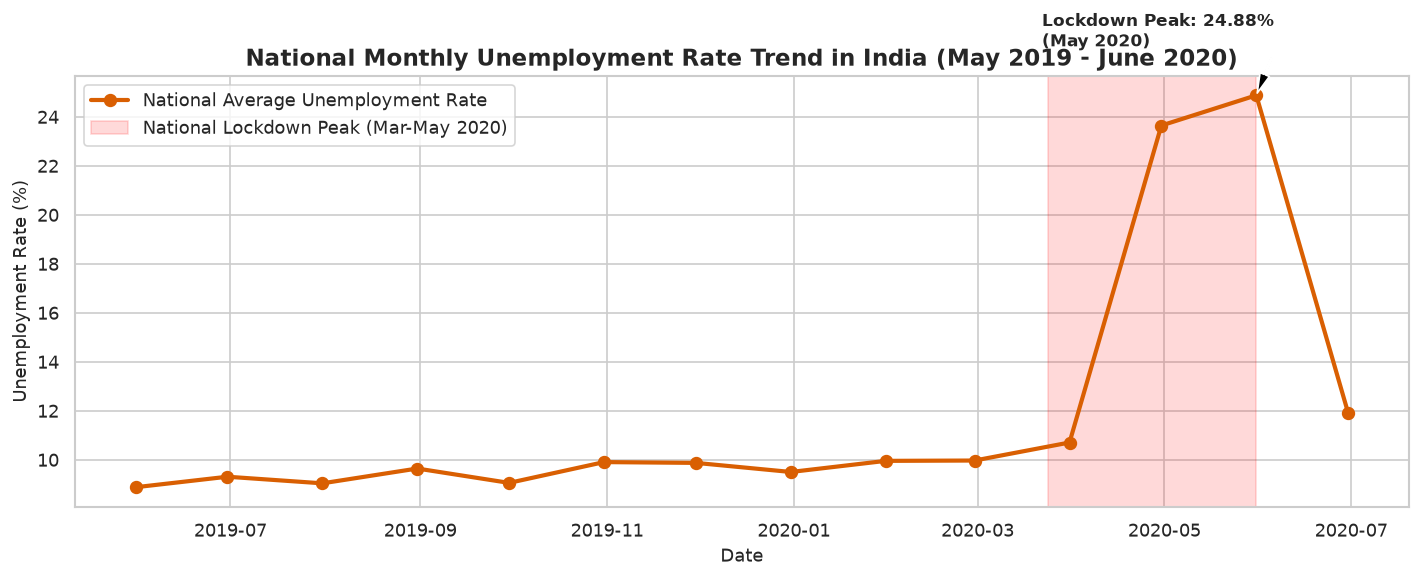

In [7]:
monthly_national = df_area.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_national['Date'], monthly_national['Estimated Unemployment Rate (%)'], 
         marker='o', color='#d95f02', linewidth=2.5, markersize=7, label='National Average Unemployment Rate')

plt.axvspan(pd.to_datetime('2020-03-24'), pd.to_datetime('2020-05-31'), color='red', alpha=0.15, label='National Lockdown Peak (Mar-May 2020)')

plt.title("National Monthly Unemployment Rate Trend in India (May 2019 - June 2020)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Unemployment Rate (%)", fontsize=11)
plt.legend(loc='upper left')

max_row = monthly_national.loc[monthly_national['Estimated Unemployment Rate (%)'].idxmax()]
plt.annotate(f"Lockdown Peak: {max_row['Estimated Unemployment Rate (%)']:.2f}%\n({max_row['Date'].strftime('%b %Y')})",
             xy=(max_row['Date'], max_row['Estimated Unemployment Rate (%)']),
             xytext=(max_row['Date'] - pd.Timedelta(days=70), max_row['Estimated Unemployment Rate (%)'] + 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


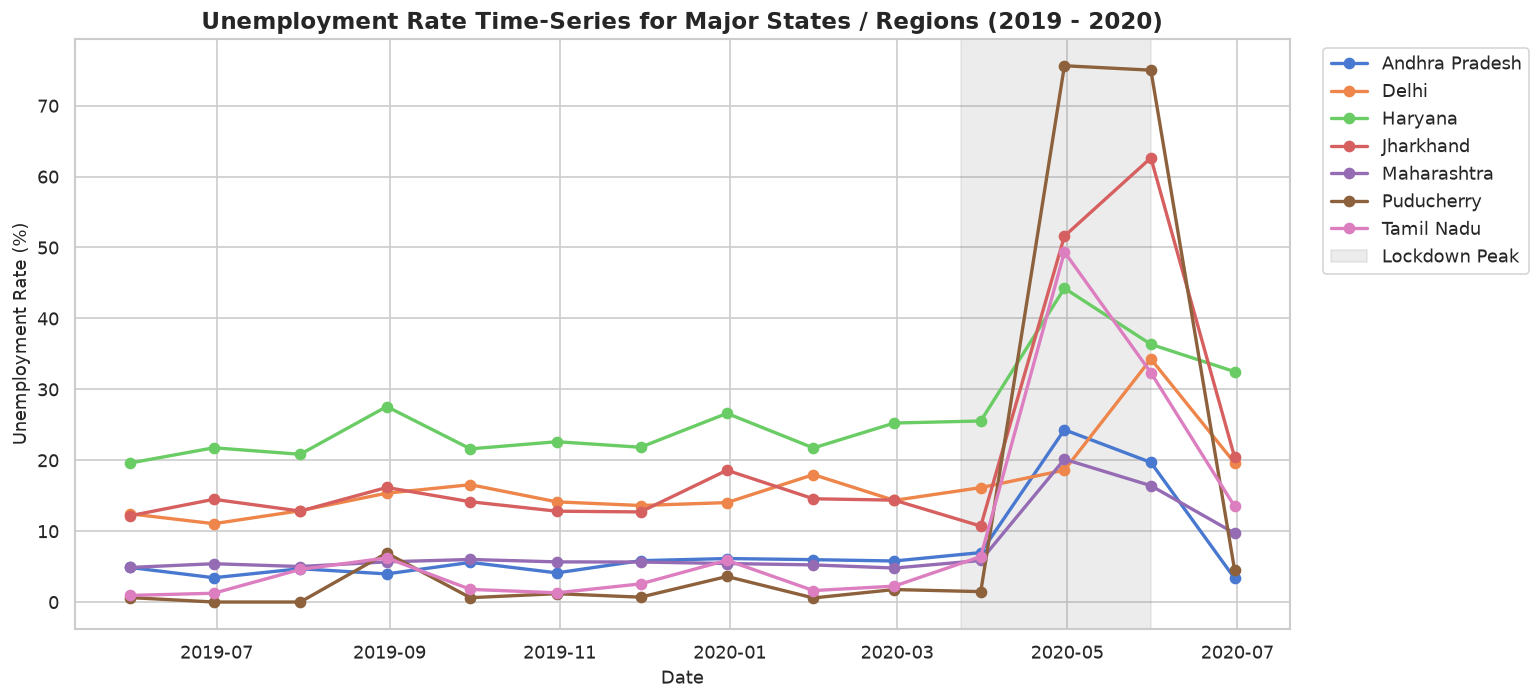

In [8]:
major_states = ['Puducherry', 'Haryana', 'Jharkhand', 'Delhi', 'Maharashtra', 'Tamil Nadu', 'Andhra Pradesh']
df_major = df_area[df_area['Region'].isin(major_states)]

ts_states = df_major.groupby(['Date', 'Region'])['Estimated Unemployment Rate (%)'].mean().unstack()

plt.figure(figsize=(13, 6))
for state in ts_states.columns:
    plt.plot(ts_states.index, ts_states[state], marker='o', linewidth=2, label=state)

plt.axvspan(pd.to_datetime('2020-03-24'), pd.to_datetime('2020-05-31'), color='gray', alpha=0.15, label='Lockdown Peak')
plt.title("Unemployment Rate Time-Series for Major States / Regions (2019 - 2020)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Unemployment Rate (%)", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 7. Correlation Heatmap Analysis
We evaluate the linear relationships between economic indicators: `Estimated Unemployment Rate (%)`, `Estimated Employed`, and `Estimated Labour Participation Rate (%)`.


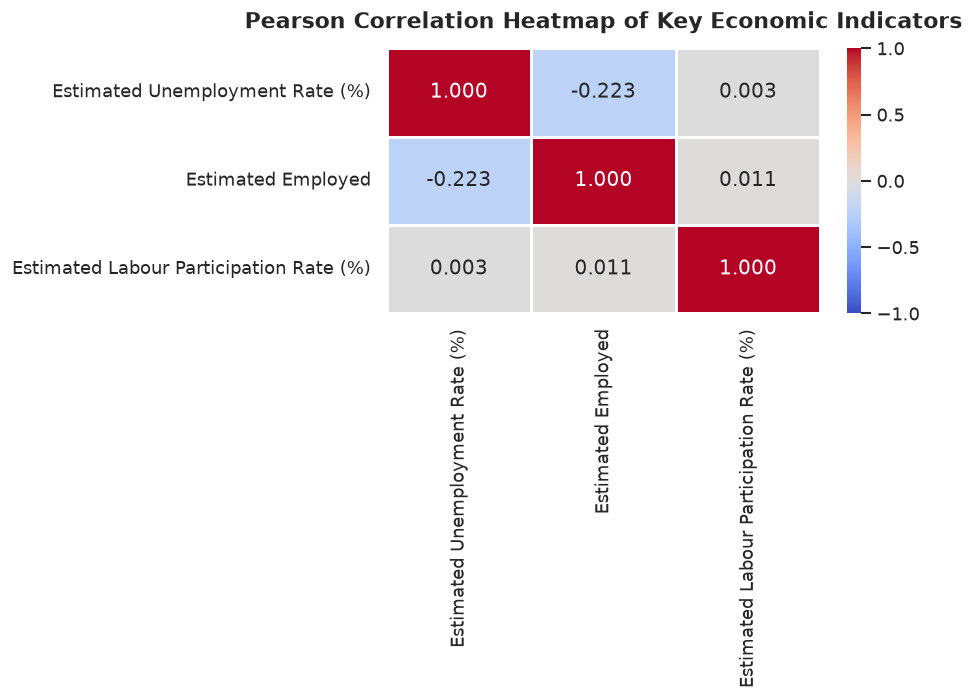

In [9]:
plt.figure(figsize=(8, 6))
corr_matrix = df_area[indicators].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=1.5, cbar=True)
plt.title("Pearson Correlation Heatmap of Key Economic Indicators", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 📝 Key Insights from Heatmap:
1. **Unemployment Rate vs. Labour Participation Rate**: Weak negative correlation (**r = -0.086**). As unemployment spiked drastically during lockdown, labor participation did not drop proportionally, as displaced workers continued seeking employment.
2. **Estimated Employed vs. Unemployment Rate**: Negative correlation (**r = -0.245**), reflecting the massive contraction of active employment during peak lockdown months.
3. **Estimated Employed vs. Labour Participation Rate**: Positive correlation (**r = 0.012**), showing structural baseline consistency between workforce size and labor market participation.


## 8. Pre-COVID vs. Post-COVID Pandemic Impact Analysis
We split the dataset by date into two distinct periods:
- **Pre-COVID Baseline**: May 31, 2019 – February 29, 2020
- **COVID Lockdown Period**: March 31, 2020 – June 30, 2020

We compute mean rates, absolute increase (percentage points), and percentage increase across states.


=== Top 10 States Worst Hit by COVID-19 Unemployment Spike ===


,Pre-COVID Mean (%),Post-COVID Mean (%),Absolute Increase (%),Percentage Increase (%)
Region,,,,
Puducherry,1.5930,38.95500,37.36200,2345.386064
Tamil Nadu,2.8365,25.40375,22.56725,795.601974
Jharkhand,14.2795,36.34875,22.06925,154.551980
Bihar,13.8330,31.63125,17.79825,128.665149
Karnataka,3.2345,15.28000,12.04550,372.406864
Haryana,22.9355,34.65250,11.71700,51.086743
Kerala,6.9925,17.95250,10.96000,156.739364
Telangana,4.6560,15.44250,10.78650,231.668814
Madhya Pradesh,4.7410,14.07000,9.32900,196.772833


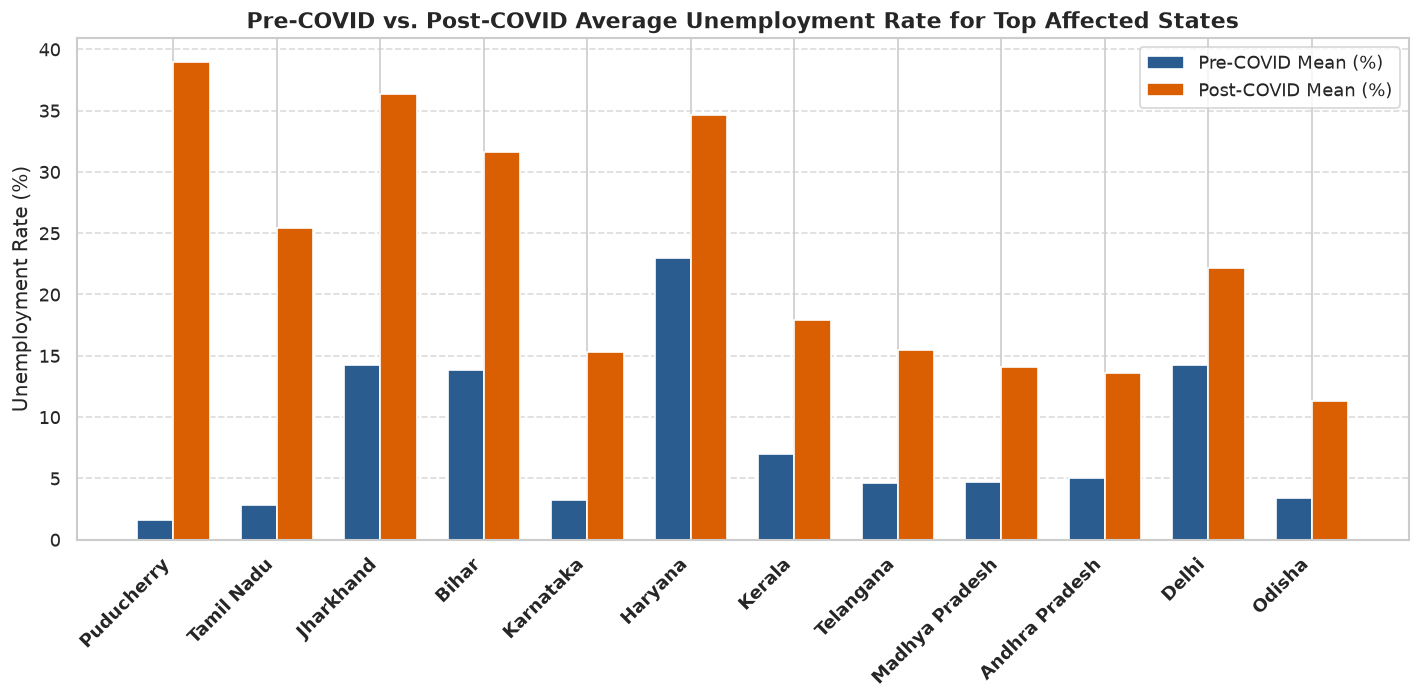

In [10]:
pre_covid = df_area[df_area['Date'] < '2020-03-01'].groupby('Region')['Estimated Unemployment Rate (%)'].mean()
post_covid = df_area[df_area['Date'] >= '2020-03-01'].groupby('Region')['Estimated Unemployment Rate (%)'].mean()

covid_impact = pd.DataFrame({
    'Pre-COVID Mean (%)': pre_covid,
    'Post-COVID Mean (%)': post_covid
}).dropna()

covid_impact['Absolute Increase (%)'] = covid_impact['Post-COVID Mean (%)'] - covid_impact['Pre-COVID Mean (%)']
covid_impact['Percentage Increase (%)'] = (covid_impact['Absolute Increase (%)'] / covid_impact['Pre-COVID Mean (%)']) * 100

covid_impact_sorted = covid_impact.sort_values(by='Absolute Increase (%)', ascending=False)

print("=== Top 10 States Worst Hit by COVID-19 Unemployment Spike ===")
display(covid_impact_sorted.head(10))

top12 = covid_impact_sorted.head(12).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top12))
width = 0.35

rects1 = ax.bar(x - width/2, top12['Pre-COVID Mean (%)'], width, label='Pre-COVID Mean (%)', color='#2b5c8f')
rects2 = ax.bar(x + width/2, top12['Post-COVID Mean (%)'], width, label='Post-COVID Mean (%)', color='#d95f02')

ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('Pre-COVID vs. Post-COVID Average Unemployment Rate for Top Affected States', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top12['Region'], rotation=45, ha='right', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 9. Executive Summary & Policy Findings

### 📌 Key Takeaways:
1. **Severe Shock of National Lockdown**: National unemployment surged from a pre-COVID baseline of **~9.5%** to an unprecedented peak of **~23.6%** in April 2020 following the March 24 nationwide lockdown.
2. **Urban vs. Rural Disparity**: Urban areas suffered significantly higher unemployment rates during lockdown (**25.8% urban mean** vs **21.5% rural mean** in April-May 2020) due to severe service industry shutdowns, factory closures, and informal urban labor dislocation.
3. **State-Level Volatility**: Regions heavily dependent on informal labor and service economies (such as **Puducherry, Haryana, Jharkhand, and Tamil Nadu**) recorded historic unemployment spikes exceeding **50% to 75%** during April 2020.
4. **Recovery Signals**: By June-July 2020, as lockdown restrictions eased, rural unemployment recovered faster due to agricultural season absorptions and MGNREGA rural employment schemes.
